In [15]:
# Core LSD imports
from sclsd.train import LSD
from sclsd.core import LSDConfig
# Scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#GSEA analysis
import gseapy as gp
# Deep learning
import torch

# Single-cell analysis
import scanpy as sc

from tqdm.auto import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
#read the adata
data_path = "../../Zenodo/Mouse_Cortex/preprocessed_adata_train.h5ad"
adata = sc.read(data_path)

#intialize LSD model
cfg = LSDConfig()
cfg.model.layer_dims.potential = [16,16]
lsd = LSD(
    adata,
    cfg,
    device=device,)

#load the trained model
model_dir = "./model"
model_path = "lsd_model_epoch0100.pth"
lsd.load(model_dir, model_path)

#extract LSD outputs (transition matrix, potantial, entropy, pseudotime)
final_adata = lsd.get_adata()

#predict cell fates
dyn_adata = lsd.get_cell_fates(final_adata , time_range = 20, cluster_key = "clusters")

[LSD] Model and Pyro parameters loaded from ./model/lsd_model_epoch0100.pth


/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/sclsd/train/trainer.py:894: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predicted_fates = adata.obs[cluster_key][nn.cpu().numpy()].values


plotting LSD outputs on UMAP projection


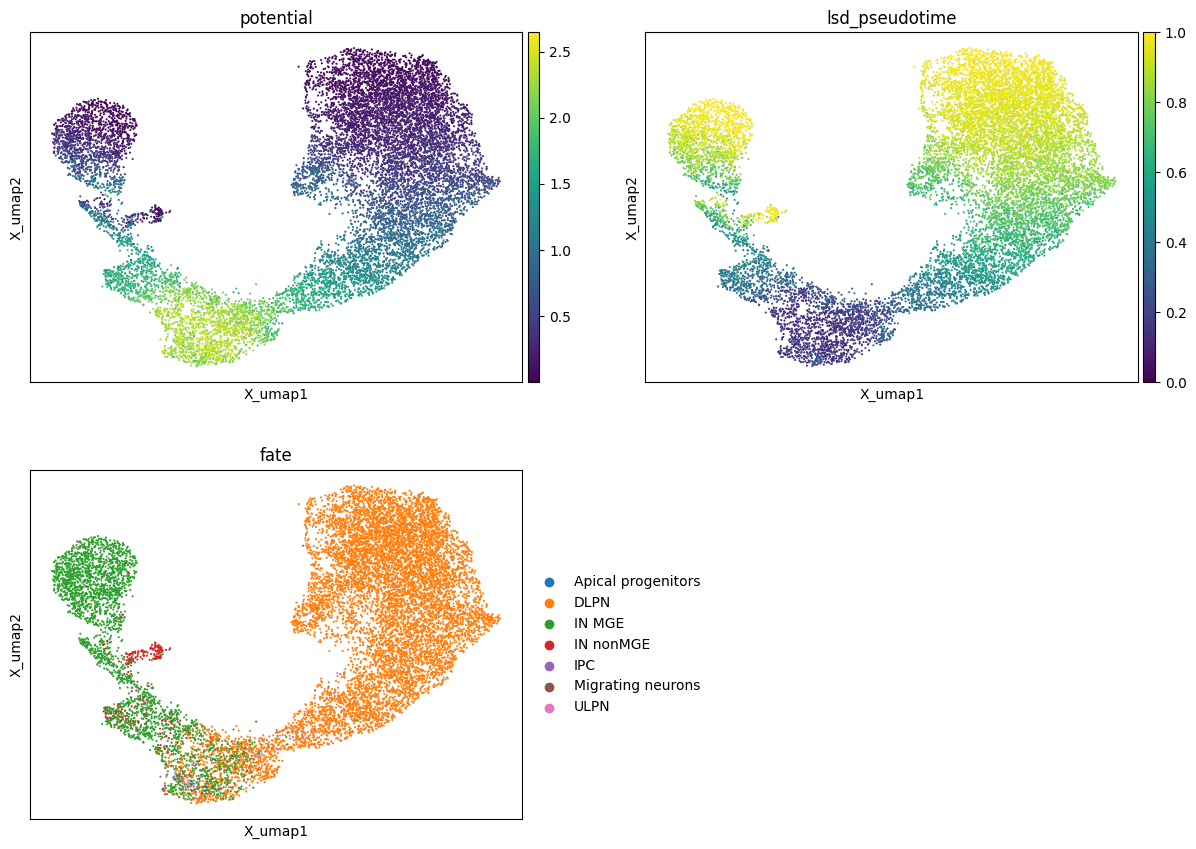

plotting LSD outputs on diffrentiation state projection


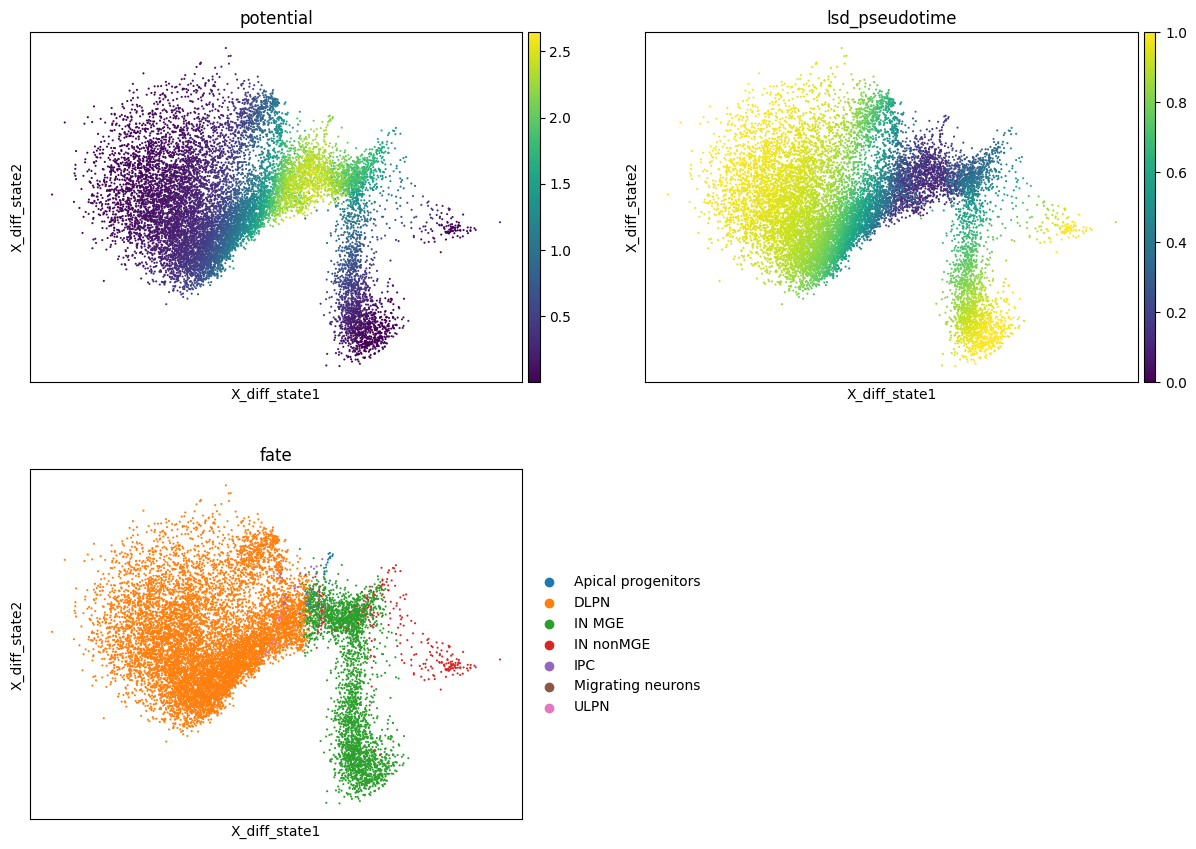

plotting LSD streamlines on UMAP projection


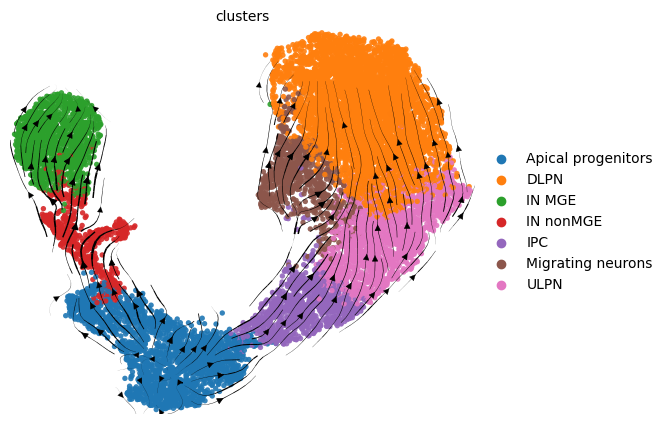

plotting LSD streamlines on diffrentiation state projection


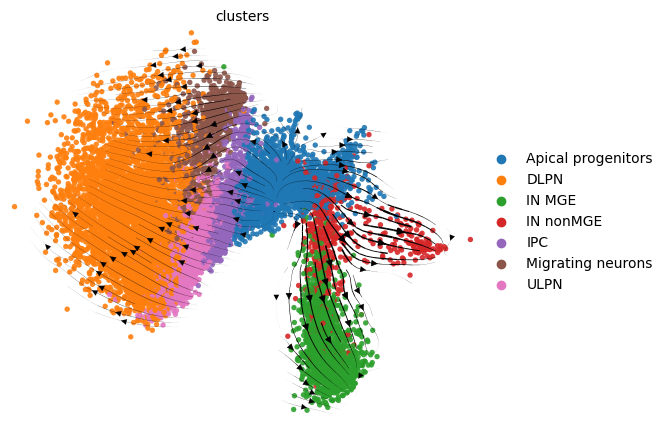

<Axes: title={'center': 'clusters'}>

In [ ]:
#plot lsd outputs
cols = ["potential", "lsd_pseudotime", "fate"]
dyn_adata.uns["fate_colors"] = dyn_adata.uns["clusters_colors"]

print("="* 60)
print("plotting LSD outputs on UMAP projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_umap", ncols = 2)

print("="* 60)
print("plotting LSD outputs on diffrentiation state projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_diff_state", ncols = 2)

print("="* 60)
print("plotting LSD streamlines on UMAP projection")
print("="* 60)
lsd.stream_lines(embedding= "X_umap", size = 60)

print("="* 60)
print("plotting LSD streamlines on diffrentiation state projection")
print("="* 60)
lsd.stream_lines(embedding= "X_diff_state", size = 60)

In [9]:
#large scale gene KO for Apical progenitors
rows = []
x = torch.from_numpy(dyn_adata.X.toarray()) 
idx = np.where(dyn_adata.obs['clusters'] == "Apical progenitors")[0]
IC = x[idx].to(device)
EX = ["DLPN", "ULPN"]
IN = ["IN MGE", "IN nonMGE"]
for i, gene in enumerate(tqdm(adata.var_names, 
                              desc="Perturbing genes",
                              total=len(adata.var_names))):
    perturbed_fates, unperturbed_fates = lsd.perturb(
    adata=dyn_adata,
    x=IC,
    gene_name=gene,
    cluster_key="clusters",
    batch_size= 4096
    )

    pert_count_ex = np.sum(np.isin(perturbed_fates, EX))
    unpert_count_ex = np.sum(np.isin(unperturbed_fates, EX))
    pert_count_in = np.sum(np.isin(perturbed_fates, IN))
    unpert_count_in =np.sum(np.isin(unperturbed_fates, IN))
    
    # Calculate log fold changes
    # Add pseudocount to avoid division by zero
    pseudocount = 0
    logFC_ex = np.log2((pert_count_ex + pseudocount) / (unpert_count_ex + pseudocount))
    logFC_in = np.log2((pert_count_in + pseudocount) / (unpert_count_in + pseudocount))
    
    # Store results
    rows.append({
        "Gene": gene,
        "Perturbed_excitatory_count": pert_count_ex,
        "Unperturbed_excitatory_count": unpert_count_ex,
        "Perturbed_inhibtory_count": pert_count_in,
        "Unperturbed_inhibtory_count": unpert_count_in,
        "excitatory_LogFC": logFC_ex,
        "inhibtory_LogFC": logFC_in,
        "Total_cells": len(IC)
    })
df = pd.DataFrame(rows)


Perturbing genes:   0%|          | 0/1062 [00:00<?, ?it/s]

Perturbing genes: 100%|██████████| 1062/1062 [1:18:46<00:00,  4.45s/it]


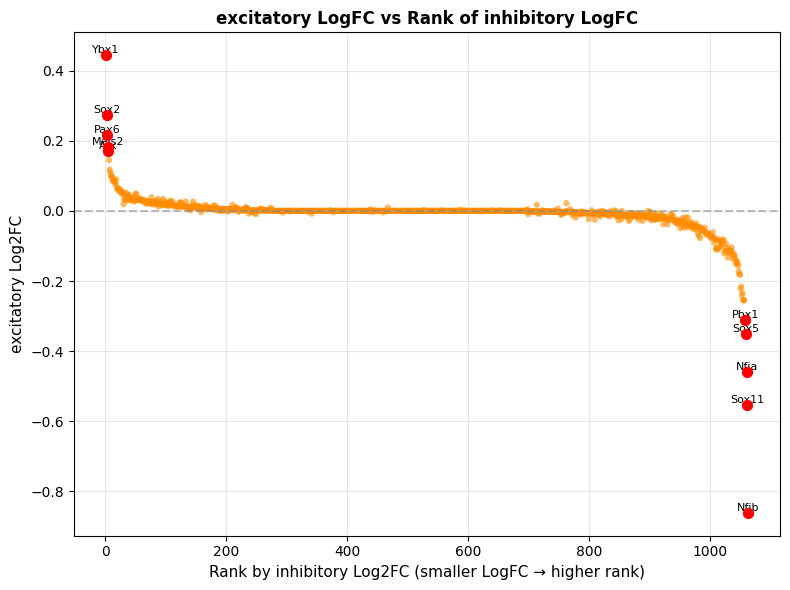

In [10]:
# Rank genes based on their influence (higher rank = higher influence on inhibtory lineage)
df_clean = df.dropna()
df_ranked = df_clean.copy()
df_ranked['inhibtory_rank'] = df_ranked['inhibtory_LogFC'].rank(method='first', ascending=True).astype(int)
df_ranked = df_ranked.sort_values('inhibtory_LogFC')
top_noto_positive = df_clean.nlargest(10, 'inhibtory_LogFC')[['Gene', 'inhibtory_LogFC']]
top_noto_negative = df_clean.nsmallest(10, 'inhibtory_LogFC')[['Gene', 'inhibtory_LogFC']]
# Create figure
plt.figure(figsize=(8, 6))

plt.scatter(df_ranked['inhibtory_rank'], df_ranked['excitatory_LogFC'],
            alpha=0.6, s=20, c='darkorange', edgecolor='none')

# Highlight top genes (if you want — optional)
top_genes_noto = pd.concat([top_noto_positive.head(5), top_noto_negative.head(5)])
if 'Gene' in df_ranked.columns:
    mark_df = df_ranked[df_ranked['Gene'].isin(top_genes_noto['Gene'])]
    plt.scatter(mark_df['inhibtory_rank'], mark_df['excitatory_LogFC'],
                color='red', s=50, zorder=5)
    for _, row in mark_df.iterrows():
        plt.annotate(row['Gene'],
                     (row['inhibtory_rank'], row['excitatory_LogFC']),
                     fontsize=8, ha='center', va='bottom')

# Reference line at y=0
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Labels & title
plt.xlabel('Rank by inhibitory Log2FC (smaller LogFC → higher rank)', fontsize=11)
plt.ylabel('excitatory Log2FC', fontsize=11)
plt.title('excitatory LogFC vs Rank of inhibitory LogFC', fontsize=12, fontweight='bold')

# Styling
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


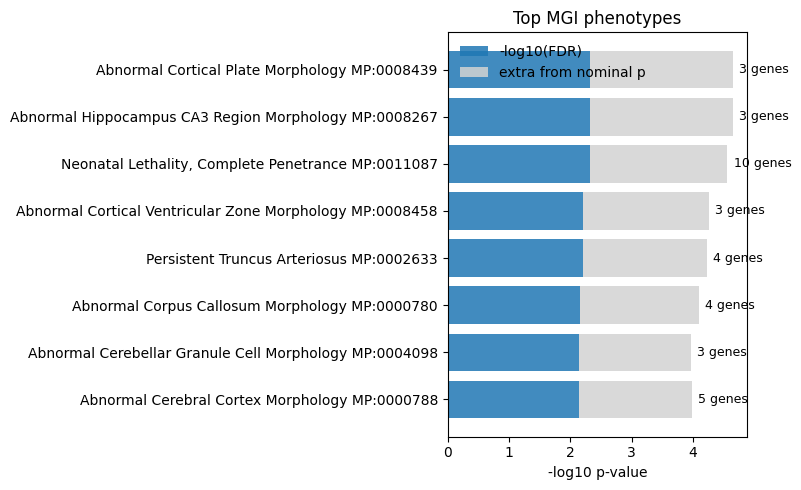

In [16]:
# Enrichr over MGI Mammalian Phenotypes (mouse):
# 1) pick the top +/- genes by inhibitory_LogFC
# 2) run Enrichr using dyn_adata genes as the background universe
# 3) plot top enriched phenotype terms as stacked bars:
#    blue = -log10(FDR-adjusted p), grey = extra significance from nominal p

thresh, top_n = 10, 8
lib = "MGI_Mammalian_Phenotype_Level_4_2024"

# --- Gene list: top up + top down, uppercased, and restricted to genes present in dyn_adata ---
universe = set(dyn_adata.var_names.str.upper())
hits = pd.concat([
    df_clean.nlargest(thresh, "inhibtory_LogFC")[["Gene"]],
    df_clean.nsmallest(thresh, "inhibtory_LogFC")[["Gene"]],
])["Gene"].str.upper().dropna().unique()
hits = [g for g in hits if g in universe]
if len(hits) < 5:
    raise ValueError("Need ≥5 genes for a meaningful Enrichr call.")

# --- Enrichment (no files written) ---
res = gp.enrichr(
    gene_list=hits,
    background=list(universe),
    gene_sets=[lib],
    organism="Mouse",
    cutoff=0.2,      # keep FDR <= 0.2 in the returned table
    outdir=None,
    verbose=False,
).results.copy()

# --- Tidy + pick top terms ---
res["-log10_fdr"] = -np.log10(res["Adjusted P-value"].clip(1e-12))
res["-log10_p"]   = -np.log10(res["P-value"].clip(1e-300))
res["gene_hits"]  = res["Genes"].str.count(";").add(1)  # number of hit genes in each term

top = res.sort_values("Adjusted P-value").head(top_n)
terms = top["Term"].tolist()

# --- Plot: stacked bar = adjusted part (blue) + residual from nominal p (grey) ---
y = np.arange(len(terms))
adj = top["-log10_fdr"].to_numpy()
nom = top["-log10_p"].to_numpy()
resid = np.clip(nom - adj, 0, None)

plt.figure(figsize=(8, 5))
plt.barh(y, adj, label="-log10(FDR)", alpha=0.85)
plt.barh(y, resid, left=adj, color="lightgrey", label="extra from nominal p", alpha=0.85)
plt.yticks(y, terms)
plt.gca().invert_yaxis()
plt.xlabel("-log10 p-value")
plt.title("Top MGI phenotypes")
for yi, n_genes, total in zip(y, top["gene_hits"], nom):
    plt.text(total + 0.1, yi, f"{n_genes} genes", va="center", fontsize=9)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


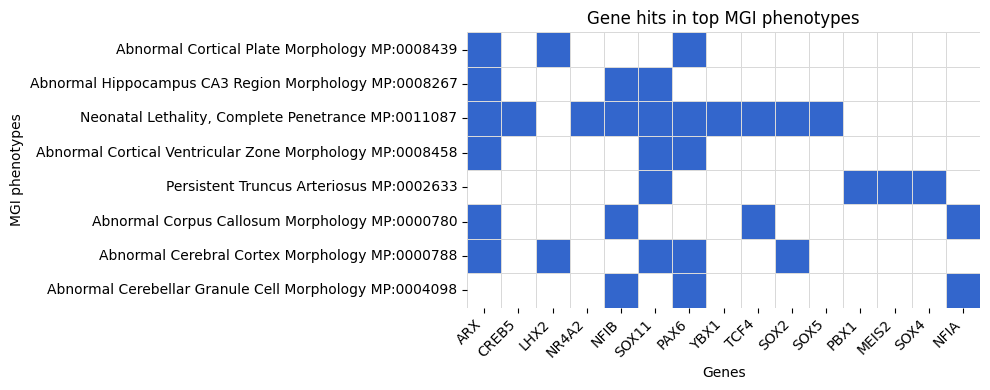

In [17]:
# Gene–phenotype association heatmap (for top Enrichr MGI terms):
# 1) take the Enrichr results table `res` (from gp.enrichr(...))
# 2) pick the top N phenotype terms (by best adjusted p-value)
# 3) explode the semicolon-separated "Genes" list into (Term, Gene) pairs
# 4) pivot to a binary matrix: rows=terms, cols=genes, 1 if gene is listed for that term
# 5) order genes by their strongest term significance (max -log10 FDR across selected terms)
# 6) plot a simple binary heatmap

top_n = 8
mgi = res.copy()
# --- Top terms + long (Term, Gene) table ---
top_terms = mgi.nsmallest(top_n, "Adjusted P-value")["Term"].tolist()

hits = (mgi[mgi["Term"].isin(top_terms)]
        .assign(Gene=mgi["Genes"].str.split(";"))
        .explode("Gene"))
hits["Gene"] = hits["Gene"].str.strip()

# --- Gene order: most significant anywhere among selected terms first ---
hits["-log10_fdr"] = -np.log10(hits["Adjusted P-value"].clip(1e-12))
gene_order = hits.groupby("Gene")["-log10_fdr"].max().sort_values(ascending=False).index

# --- Binary association matrix + plot ---
assoc = (hits.assign(v=1)
         .pivot_table(index="Term", columns="Gene", values="v", aggfunc="max", fill_value=0)
         .reindex(index=top_terms, columns=gene_order))

plt.figure(figsize=(10, 4))
sns.heatmap(assoc, cmap=["white", "#3366cc"], cbar=False, linewidths=0.5, linecolor="0.85")
plt.xlabel("Genes"); plt.ylabel("MGI phenotypes"); plt.title("Gene hits in top MGI phenotypes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()
